# Aurora vs Pangu-Weather vs Ground Truth

Первое сравнение двух transformer-based моделей погоды: **Aurora** (Microsoft, 0.25° pretrained, 1.26B параметров,
PyTorch) и **Pangu-Weather** (Huawei, 24h ONNX). Оба дают прогноз на +24h для трёх кейсов
(Storm Eunice, волна тепла/блокинг, спокойный день), сравниваем с реальными ERA5 (ground truth) на valid time.

**Важное отличие в подготовке данных**: Pangu берёт один входной снимок (t), Aurora — два (t-6h и t) — модель
работает 6-часовыми шагами, для +24h нужен ручной 4-шаговый rollout (детали и обход известного memory-бага
`aurora.rollout()` — в `run_case_aurora.py`).

**Известная разница в сетках**: Aurora обрезает южный полюс (720 широт: 90°...−89.75°, без −90°), тогда как
Pangu/ARCO дают 721 (включая −90°). Здесь всё выравнивается по сетке Aurora (720 широт) для честного сравнения.


In [1]:
import pickle
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.rcParams['figure.dpi'] = 110

PRESSURE_LEVELS_HPA = [1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100, 50]  # Pangu order
SURFACE_ORDER = ['mean_sea_level_pressure', '10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature']

# Aurora short names -> ARCO long names (same physical variables, different key convention)
AURORA_TO_LONG = {'msl': 'mean_sea_level_pressure', '10u': '10m_u_component_of_wind',
                  '10v': '10m_v_component_of_wind', '2t': '2m_temperature'}

CASES = ['storm_eunice', 'heatwave_block', 'quiet_baseline']
CASE_DATES = {
    'storm_eunice':   '2022-02-18T12:00',
    'heatwave_block': '2022-07-18T12:00',
    'quiet_baseline': '2021-10-05T12:00',
}


## 1. Загрузка обоих прогнозов


In [2]:
pangu_results = {}
aurora_results = {}
for case in CASES:
    with open(f'results/{case}.pkl', 'rb') as f:
        pangu_results[case] = pickle.load(f)
    with open(f'results/{case}_aurora_baseline.pkl', 'rb') as f:
        aurora_results[case] = pickle.load(f)

print('Pangu output_surface shape:', pangu_results[CASES[0]]['baseline_output'][0].shape, '(4, 721, 1440)')
print('Aurora msl shape:', aurora_results[CASES[0]]['surf_vars']['msl'].shape, '(1, 1, 720, 1440)')


Pangu output_surface shape: (4, 721, 1440) (4, 721, 1440)
Aurora msl shape: (1, 1, 720, 1440) (1, 1, 720, 1440)


## 2. Ground truth (ERA5 на valid time = case_time + 24h)


In [3]:
ARCO_URL = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
ds_arco = xr.open_zarr(ARCO_URL, storage_options=dict(token='anon'), chunks=None)
ds_arco = ds_arco.assign_coords(longitude=(ds_arco.longitude % 360)).sortby('longitude')


def fetch_truth_surface(case_key):
    valid_time = np.datetime64(CASE_DATES[case_key]) + np.timedelta64(24, 'h')
    snapshot = ds_arco.sel(time=valid_time, method='nearest')
    return {v: snapshot[v].values for v in SURFACE_ORDER}, valid_time


truth_by_case = {}
for case in CASES:
    truth_by_case[case], valid_time = fetch_truth_surface(case)
    print(case, '-> valid time:', valid_time)


/home/irina/venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


/home/irina/venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.cloud._storage_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud._storage_v2 past that date.
  warnings.warn(message, FutureWarning)
/home/irina/venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)


storm_eunice -> valid time: 2022-02-19T12:00


heatwave_block -> valid time: 2022-07-19T12:00


quiet_baseline -> valid time: 2021-10-06T12:00


## 3. Выравнивание сеток (721 -> 720, обрезаем южный полюс) и сравнение RMSE


In [4]:
def crop_to_720(field_721):
    """Aurora's output grid drops the last (south pole, -90deg) latitude row."""
    return field_721[:-1]


def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))


comparison_rows = []
for case in CASES:
    pangu_surf = pangu_results[case]['baseline_output'][0]  # (4, 721, 1440), order = SURFACE_ORDER
    truth = truth_by_case[case]

    for i, var in enumerate(SURFACE_ORDER):
        pangu_field = crop_to_720(pangu_surf[i])
        truth_field = crop_to_720(truth[var])

        aurora_key = [k for k, v in AURORA_TO_LONG.items() if v == var][0]
        aurora_field = aurora_results[case]['surf_vars'][aurora_key][0, 0]  # (720, 1440)

        comparison_rows.append({
            'case': case, 'variable': var,
            'pangu_rmse': rmse(pangu_field, truth_field),
            'aurora_rmse': rmse(aurora_field, truth_field),
        })

for row in comparison_rows:
    print(row)


{'case': 'storm_eunice', 'variable': 'mean_sea_level_pressure', 'pangu_rmse': 69.4474105834961, 'aurora_rmse': 70.19380950927734}
{'case': 'storm_eunice', 'variable': '10m_u_component_of_wind', 'pangu_rmse': 0.8974099159240723, 'aurora_rmse': 0.7910547852516174}
{'case': 'storm_eunice', 'variable': '10m_v_component_of_wind', 'pangu_rmse': 0.9446846842765808, 'aurora_rmse': 0.8271023631095886}
{'case': 'storm_eunice', 'variable': '2m_temperature', 'pangu_rmse': 0.851599931716919, 'aurora_rmse': 0.7277480959892273}
{'case': 'heatwave_block', 'variable': 'mean_sea_level_pressure', 'pangu_rmse': 87.19681549072266, 'aurora_rmse': 66.80529022216797}
{'case': 'heatwave_block', 'variable': '10m_u_component_of_wind', 'pangu_rmse': 0.9501864314079285, 'aurora_rmse': 0.8052893877029419}
{'case': 'heatwave_block', 'variable': '10m_v_component_of_wind', 'pangu_rmse': 0.9604854583740234, 'aurora_rmse': 0.827160120010376}
{'case': 'heatwave_block', 'variable': '2m_temperature', 'pangu_rmse': 0.816652

## 4. Визуализация: RMSE Pangu vs Aurora, по кейсам и переменным

MSLP в Паскалях доминирует по шкале (единицы разные) — строим отдельную панель на переменную, а не один общий
bar chart, чтобы не повторить проблему с масштабом единиц из ноутбука 2.


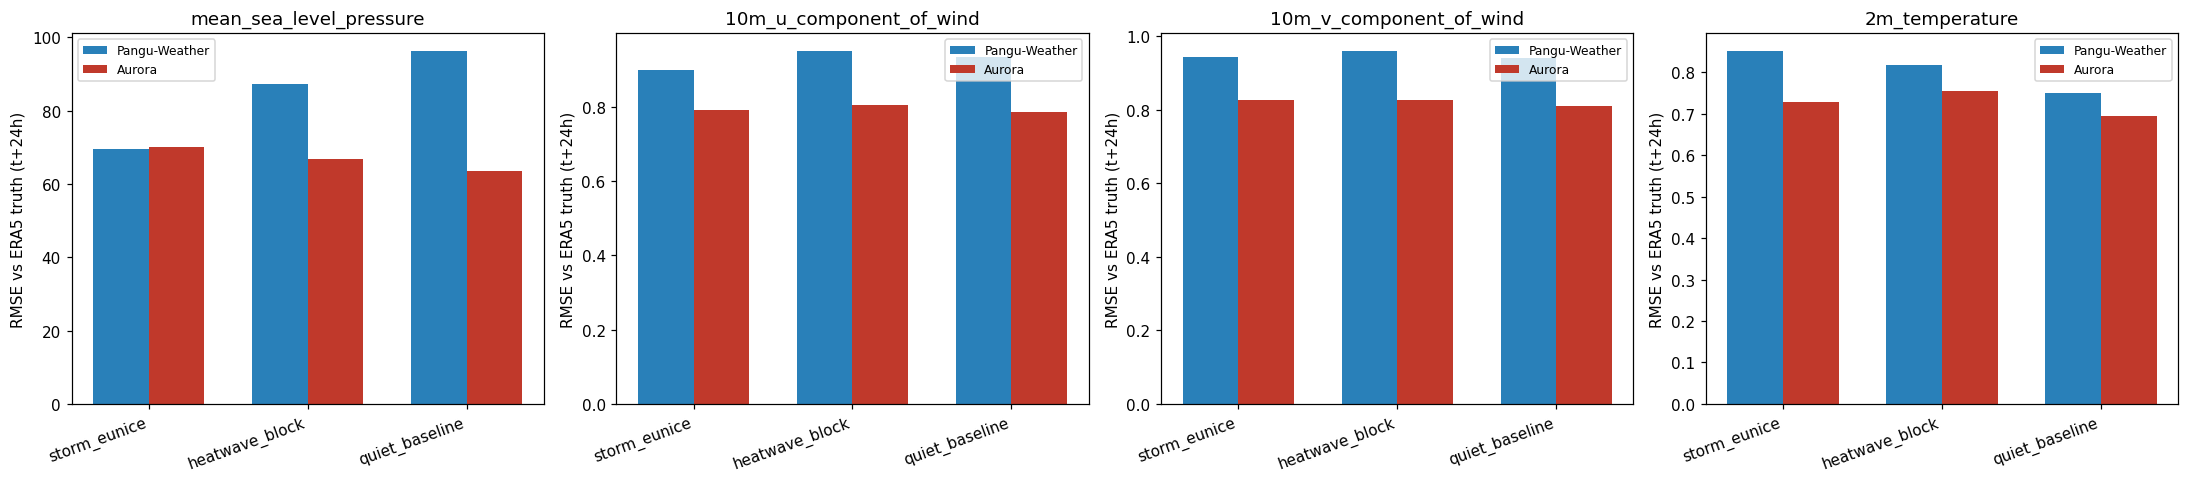

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, var in zip(axes, SURFACE_ORDER):
    rows = [r for r in comparison_rows if r['variable'] == var]
    x = np.arange(len(CASES))
    width = 0.35
    ax.bar(x - width/2, [r['pangu_rmse'] for r in rows], width, label='Pangu-Weather', color='#2980b9')
    ax.bar(x + width/2, [r['aurora_rmse'] for r in rows], width, label='Aurora', color='#c0392b')
    ax.set_xticks(x)
    ax.set_xticklabels(CASES, rotation=20, ha='right')
    ax.set_title(var)
    ax.set_ylabel('RMSE vs ERA5 truth (t+24h)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/04_aurora_vs_pangu/rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Визуальное сравнение карт MSLP: Pangu vs Aurora vs Truth (Storm Eunice)


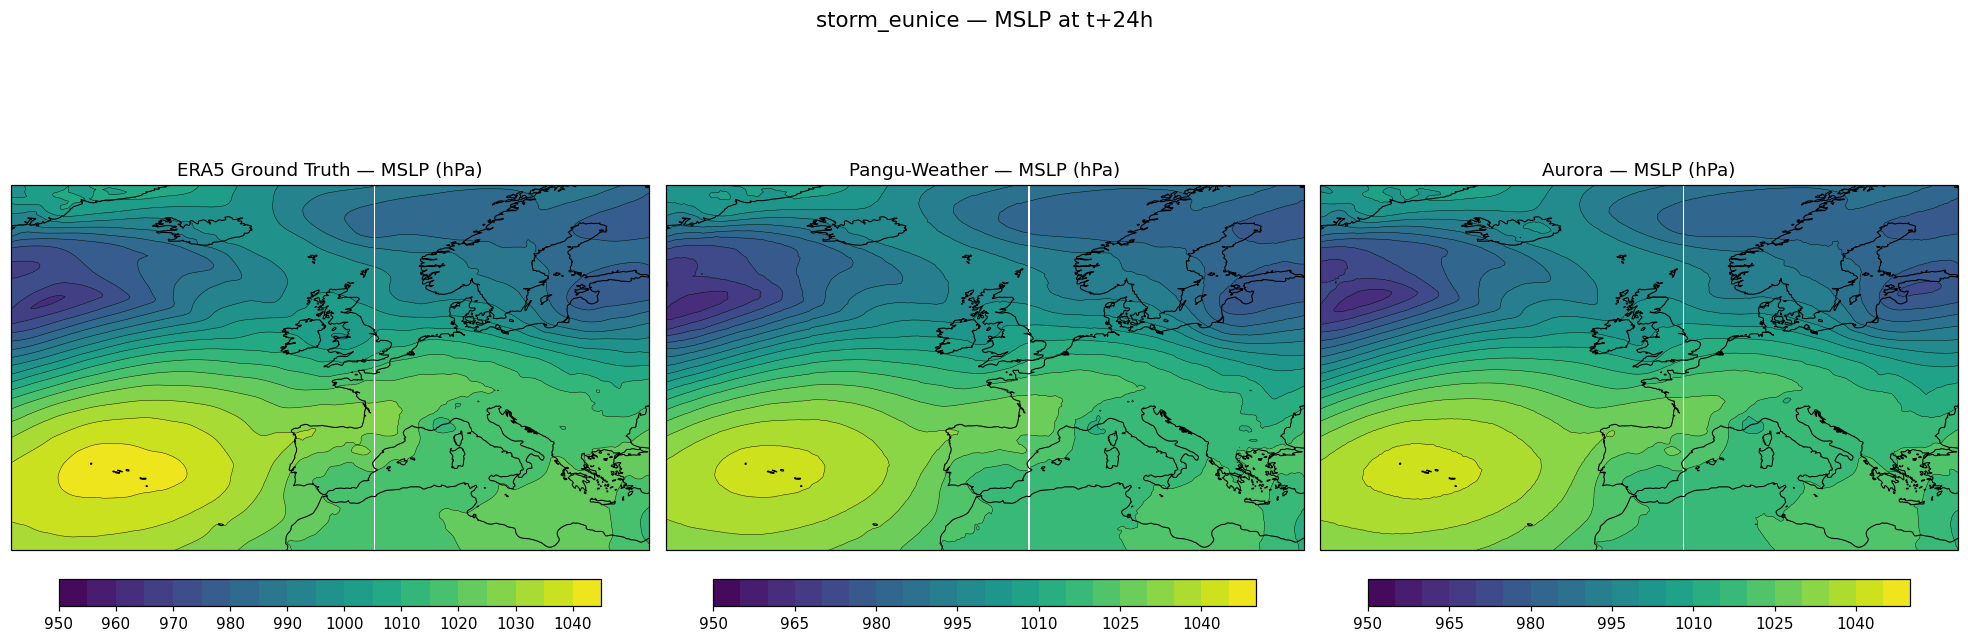

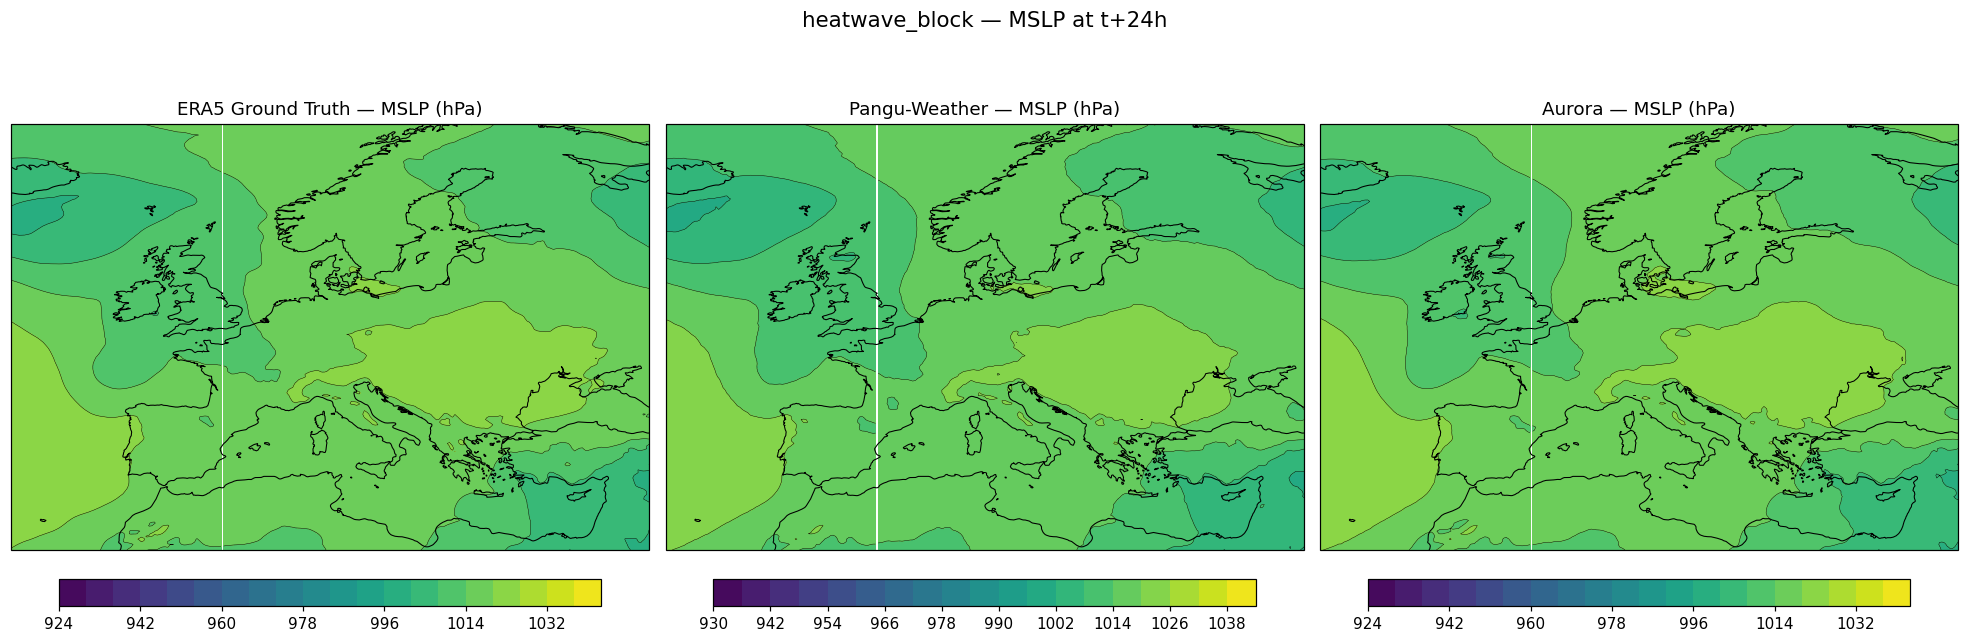

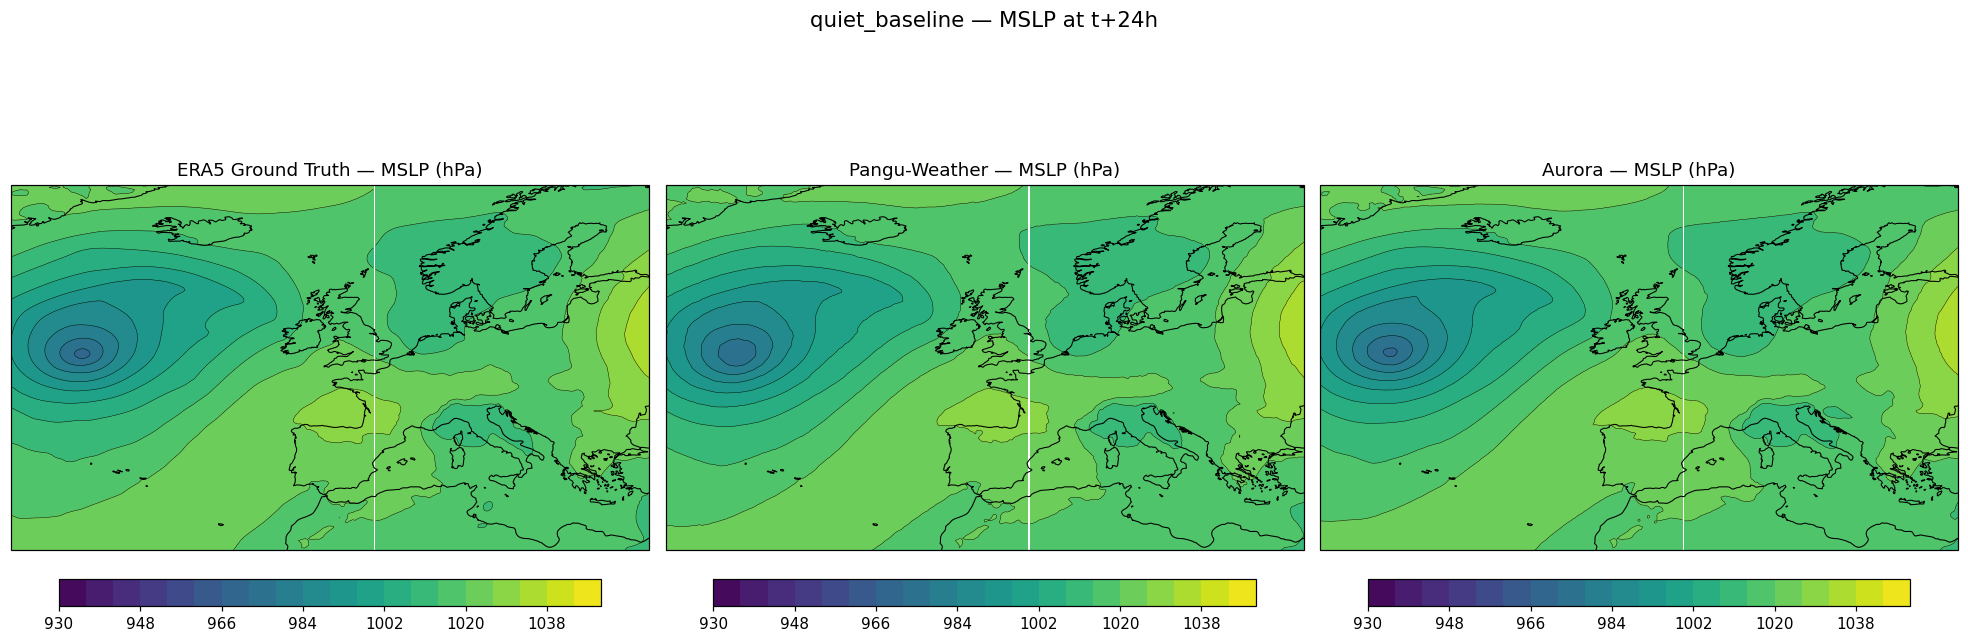

In [6]:
def plot_three_way_comparison(case, var='mean_sea_level_pressure', region=(-40, 30, 30, 70)):
    pangu_surf = pangu_results[case]['baseline_output'][0]
    var_idx = SURFACE_ORDER.index(var)
    pangu_field = crop_to_720(pangu_surf[var_idx]) / 100  # Pa -> hPa

    aurora_key = [k for k, v in AURORA_TO_LONG.items() if v == var][0]
    aurora_field = aurora_results[case]['surf_vars'][aurora_key][0, 0] / 100

    truth_field = crop_to_720(truth_by_case[case][var]) / 100

    lat = aurora_results[case]['lat']
    lon = aurora_results[case]['lon']

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    for ax, field, title in zip(axes, [truth_field, pangu_field, aurora_field],
                                 ['ERA5 Ground Truth', 'Pangu-Weather', 'Aurora']):
        ax.set_extent(region, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
        cf = ax.contourf(lon, lat, field, levels=20, cmap='viridis', transform=ccrs.PlateCarree())
        ax.contour(lon, lat, field, levels=20, colors='k', linewidths=0.3, transform=ccrs.PlateCarree())
        ax.set_title(f'{title} — MSLP (hPa)')
        plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05, shrink=0.85)

    fig.suptitle(f'{case} — MSLP at t+24h', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig(f'figures/04_aurora_vs_pangu/{case}_mslp_three_way.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_three_way_comparison('storm_eunice')
plot_three_way_comparison('heatwave_block', region=(-20, 40, 30, 70))
plot_three_way_comparison('quiet_baseline', region=(-40, 30, 30, 70))


## 6. Наблюдения

*(Заполнить после просмотра: какая модель точнее по RMSE на каждый кейс/переменную, совпадает ли визуально
положение синоптических объектов — циклон Eunice, блокинг — у обеих моделей с реальностью.)*
